# Ejercicio 6 — Parquet frente a tablas DuckDB

Este notebook muestra las dos estrategias sobre el conjunto completo (6.1 y 6.2) y analiza los resultados
del benchmark generados por `scripts/benchmark.py` (6.3 a 6.9). El benchmark tarda unos 6 minutos, por eso
se ejecuta desde la terminal y aquí se leen sus resultados (`docs/06_benchmark/results.csv`):

```bash
docker compose exec lab python scripts/build_database.py
docker compose exec lab python scripts/benchmark.py
```

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import matplotlib.pyplot as plt
import pandas as pd

import charts
import taxi_db

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)
charts.apply_style()
con = taxi_db.connect()

import time

## 6.1 Consulta directa sobre Parquet

La conexión en memoria no contiene datos: la vista `trips_clean` lee los 40 archivos Parquet en cada consulta.

In [2]:
sql = taxi_db.read_sql("04_eda/07_top_pickup_zones.sql")
start = time.perf_counter()
parquet_result = con.sql(sql).df()
print(f"Parquet directo: {time.perf_counter() - start:.3f} s")
parquet_result.head()

Parquet directo: 0.898 s


,taxi_type,borough,zone,trips,pct_of_type,rank
0,yellow,Manhattan,Upper East Side South,3150408,4.61,1
1,yellow,Manhattan,Midtown Center,3051831,4.47,2
2,yellow,Queens,JFK Airport,3005897,4.40,3
3,yellow,Manhattan,Upper East Side North,2830732,4.15,4
4,yellow,Manhattan,Midtown East,2260395,3.31,5


## 6.2 Tabla materializada

`scripts/build_database.py` copió la vista `trips` a la tabla `trips` de `data/processed/taxi.duckdb` (SQL en `sql/build/materialize.sql`) y creó allí la misma vista `trips_clean`. La consulta es idéntica; solo cambia la conexión.

In [3]:
print(taxi_db.read_sql("build/materialize.sql"))
table_con = taxi_db.connect(taxi_db.DATABASE_PATH, read_only=True, views=False)
print(table_con.sql("SELECT table_name, estimated_size, column_count FROM duckdb_tables()").df())
start = time.perf_counter()
table_result = table_con.sql(sql).df()
print(f"Tabla materializada: {time.perf_counter() - start:.3f} s")
print("Resultados idénticos:", parquet_result.equals(table_result))

CREATE OR REPLACE TABLE store.main.trips AS
SELECT *
FROM memory.main.trips;

CREATE OR REPLACE TABLE store.main.zones AS
SELECT *
FROM memory.main.zones;

  table_name  estimated_size  column_count
0      trips        71870407            26
1      zones             265             4


Tabla materializada: 0.666 s
Resultados idénticos: True


## 6.3 a 6.7 Resultados del benchmark

### Materialización por escala

In [4]:
builds = pd.read_csv(taxi_db.PROJECT_ROOT / "docs/06_benchmark/builds.csv")
builds["table_vs_parquet"] = (builds.table_mib / builds.parquet_mib).round(2)
builds

,scale,scale_label,files,rows,parquet_mib,table_mib,build_seconds,table_vs_parquet
0,1_month,1 mes (ene 2026),2,3765161,62.1,102.3,0.90,1.65
1,year_2026,Año 2026,16,30040469,495.7,816.3,3.01,1.65
2,all_years,Todos los años,40,71870407,1171.7,1972.0,7.46,1.68


### Tiempos (mediana de 5 ejecuciones)

In [5]:
results = pd.read_csv(taxi_db.PROJECT_ROOT / "docs/06_benchmark/results.csv")
summary = results.pivot_table(index=["query", "description"], columns=["scale", "strategy"], values="median_seconds")
summary = summary.reindex(columns=["1_month", "year_2026", "all_years"], level=0)
for scale in ["1_month", "year_2026", "all_years"]:
    summary[(scale, "speedup")] = summary[(scale, "parquet")] / summary[(scale, "table")]
summary = summary.reindex(columns=[(s, m) for s in ["1_month", "year_2026", "all_years"] for m in ["parquet", "table", "speedup"]])
summary.round(3)

scale                                1_month                year_2026                all_years                
strategy                             parquet  table speedup   parquet  table speedup   parquet   table speedup
query description                                                                                             
Q1    Conteo por tipo                  0.006  0.002   2.375     0.009  0.008   1.061     0.014   0.019   0.717
Q2    Volumen mensual                  0.126  0.039   3.193     0.320  0.251   1.271     0.664   0.540   1.229
Q3    Hora y día de la semana          0.155  0.043   3.630     0.380  0.264   1.442     0.809   0.576   1.404
Q4    Percentiles del viaje            0.721  0.648   1.113     5.467  5.480   0.998    16.738  15.553   1.076
Q5    Medio de pago                    0.136  0.055   2.461     0.349  0.430   0.813     0.709   0.925   0.767
Q6    Zonas principales (1 join)       0.166  0.036   4.647     0.381  0.215   1.776     0.814   0.471   1.727
Q7    Aeropuertos (2 joins)            0.182  0.049   3.696     0.481  0.326   1.476     1.004   0.757   1.326
Q8    Un solo día (filtro selectivo)   0.017  0.002   7.773     0.028  0.003  10.036     0.046   0.004  10.767

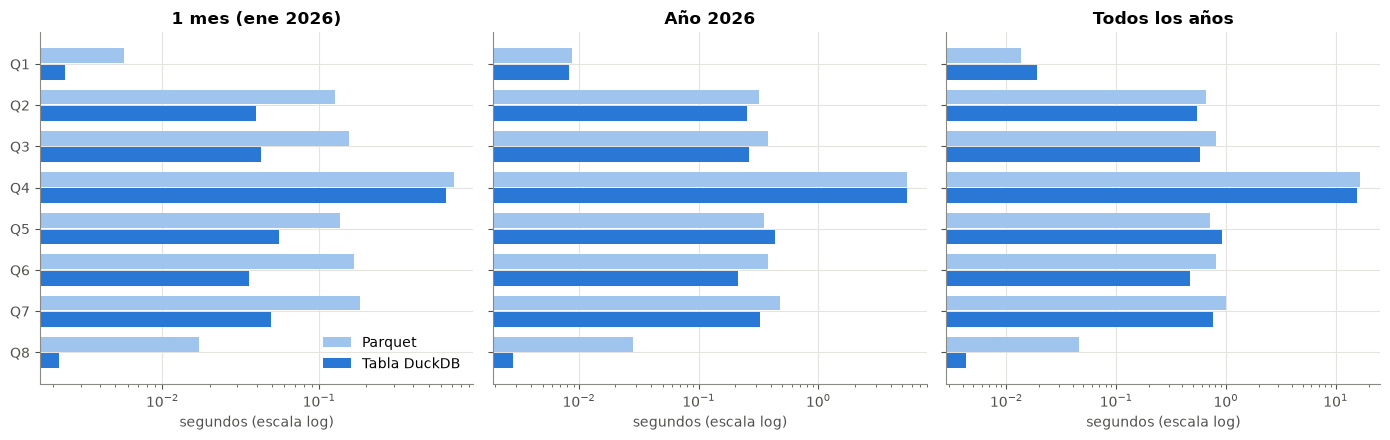

In [6]:
scales = ["1_month", "year_2026", "all_years"]
labels = dict(zip(builds.scale, builds.scale_label))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
for ax, scale in zip(axes, scales):
    data = results[results.scale == scale].pivot(index="query", columns="strategy", values="median_seconds")
    positions = range(len(data))
    ax.barh([p - 0.2 for p in positions], data.parquet, height=0.36, color="#9fc4ee", label="Parquet")
    ax.barh([p + 0.2 for p in positions], data.table, height=0.36, color="#2a78d6", label="Tabla DuckDB")
    ax.set_xscale("log")
    ax.set_yticks(list(positions), data.index)
    ax.invert_yaxis()
    ax.set_title(labels[scale])
    ax.set_xlabel("segundos (escala log)")
axes[0].legend(loc="lower right")
plt.tight_layout()
plt.show()

### 6.6 Cómo cambia la ventaja de la tabla con el volumen

Aceleración = tiempo con Parquet ÷ tiempo con la tabla. Valores mayores que 1 favorecen a la tabla.

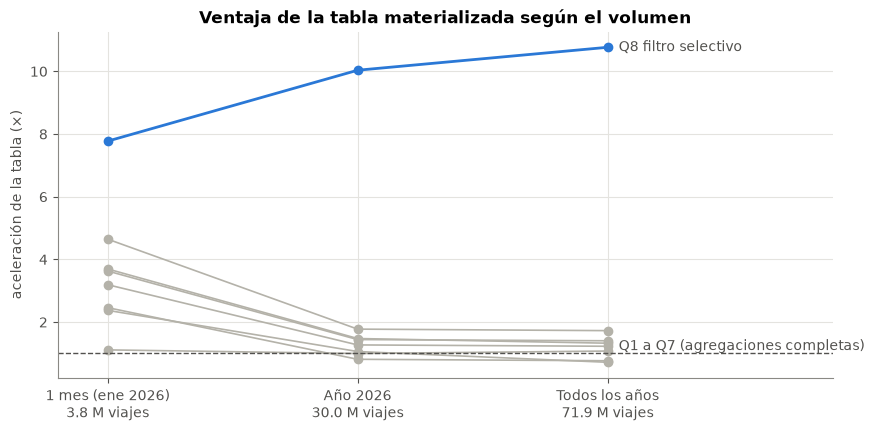

scale,1_month,year_2026,all_years
query,,,
Q1,2.38,1.06,0.72
Q2,3.19,1.27,1.23
Q3,3.63,1.44,1.40
Q4,1.11,1.00,1.08
Q5,2.46,0.81,0.77
Q6,4.65,1.78,1.73
Q7,3.70,1.48,1.33
Q8,7.77,10.04,10.77


In [7]:
speedup = results.pivot_table(index=["scale", "query"], columns="strategy", values="median_seconds")
speedup = (speedup.parquet / speedup.table).unstack("scale")[scales]
rows_by_scale = dict(zip(builds.scale, builds.rows))
positions = range(len(scales))
fig, ax = plt.subplots(figsize=(10, 4.5))
for query in speedup.index:
    highlight = query == "Q8"
    ax.plot(list(positions), speedup.loc[query], marker="o", color="#2a78d6" if highlight else "#b4b2a9", linewidth=2 if highlight else 1.2)
ax.annotate("Q8 filtro selectivo", (2, speedup.loc["Q8", "all_years"]), xytext=(8, 0), textcoords="offset points", va="center", color="#52514e")
ax.annotate("Q1 a Q7 (agregaciones completas)", (2, speedup.loc[speedup.index != "Q8", "all_years"].median()), xytext=(8, 0), textcoords="offset points", va="center", color="#52514e")
ax.axhline(1, color="#52514e", linewidth=1, linestyle="--")
ax.set_xticks(list(positions), [f"{labels[s]}\n{rows_by_scale[s] / 1e6:.1f} M viajes" for s in scales])
ax.set_xlim(-0.2, 2.9)
ax.set_ylabel("aceleración de la tabla (×)")
ax.set_title("Ventaja de la tabla materializada según el volumen")
plt.show()
speedup.round(2)